In [9]:
import numpy as np
import torch.optim as optim
import torch.nn as nn
import torch
import matplotlib.pyplot as plt

In [10]:
x = torch.linspace(-1,1,100).reshape(100,1)
y = (x**2)

In [11]:
model = nn.Sequential(
        (nn.Linear(1,16)),
        (nn.ReLU()),
        (nn.Linear(16,16)),
        (nn.ReLU()),
        (nn.Linear(16,1)),
)
print(model)

for param in model.parameters():
        print(param.shape, param)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params}")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable Parameters: {trainable_params}")

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)
torch.Size([16, 1]) Parameter containing:
tensor([[ 0.6755],
        [ 0.5732],
        [ 0.3779],
        [-0.6771],
        [ 0.7347],
        [ 0.7205],
        [ 0.3639],
        [-0.7250],
        [ 0.4566],
        [ 0.4834],
        [-0.9979],
        [ 0.9763],
        [ 0.1193],
        [-0.2304],
        [ 0.0542],
        [ 0.9145]], requires_grad=True)
torch.Size([16]) Parameter containing:
tensor([ 0.3281,  0.1694,  0.5697, -0.2654,  0.2245, -0.4545,  0.7622, -0.0642,
        -0.1623,  0.8144,  0.4286, -0.0227, -0.5155, -0.1323, -0.3367, -0.1030],
       requires_grad=True)
torch.Size([16, 16]) Parameter containing:
tensor([[-0.0752,  0.2267,  0.2327,  0.1582, -0.1846,  0.2481, -0.1500, -0.0559,
         -0.0377, -0.0720,  0.0402, -0.1874,  0.0214, -0.0698,  0.14

In [12]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(params=model.parameters(),lr=0.001)

In [ ]:
def train(input: torch.Tensor,
          expected: torch.Tensor,
          model: nn.Sequential,
          loss_fn: nn.MSELoss,
          optimizer: optim.Adam
        ) -> losses:

    size = len(input)
    losses = []
    for i,epoch in enumerate(range(10000)):
        model.train()

        pred = model(input)
        loss = loss_fn(pred,expected)
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"loss: {loss:>7f}  [{i:>5d}/{size:>5d}]") 

    return losses

loss: 0.335698  [    0/  100]
loss: 0.328320  [    1/  100]
loss: 0.321123  [    2/  100]
loss: 0.314109  [    3/  100]
loss: 0.307271  [    4/  100]
loss: 0.300610  [    5/  100]
loss: 0.294122  [    6/  100]
loss: 0.287797  [    7/  100]
loss: 0.281633  [    8/  100]
loss: 0.275619  [    9/  100]
loss: 0.269752  [   10/  100]
loss: 0.264031  [   11/  100]
loss: 0.258449  [   12/  100]
loss: 0.253001  [   13/  100]
loss: 0.247686  [   14/  100]
loss: 0.242496  [   15/  100]
loss: 0.237431  [   16/  100]
loss: 0.232483  [   17/  100]
loss: 0.227653  [   18/  100]
loss: 0.222933  [   19/  100]
loss: 0.218322  [   20/  100]
loss: 0.213816  [   21/  100]
loss: 0.209412  [   22/  100]
loss: 0.205107  [   23/  100]
loss: 0.200897  [   24/  100]
loss: 0.196806  [   25/  100]
loss: 0.192858  [   26/  100]
loss: 0.189064  [   27/  100]
loss: 0.185458  [   28/  100]
loss: 0.182033  [   29/  100]
loss: 0.178721  [   30/  100]
loss: 0.175474  [   31/  100]
loss: 0.172282  [   32/  100]
loss: 0.16

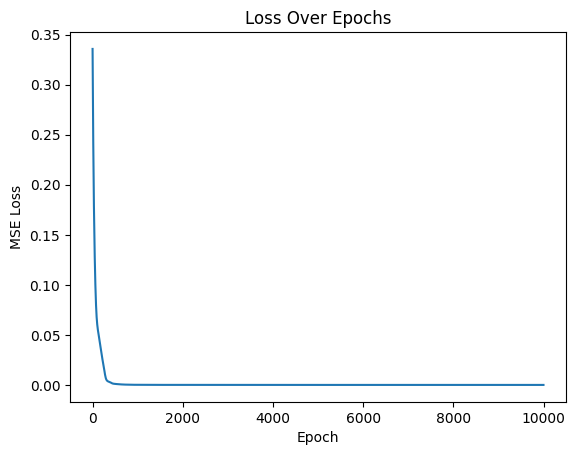

tensor([[ 9.9252e-01],
        [ 9.5660e-01],
        [ 9.2068e-01],
        [ 8.8477e-01],
        [ 8.4885e-01],
        [ 8.1294e-01],
        [ 7.7702e-01],
        [ 7.4111e-01],
        [ 7.0519e-01],
        [ 6.6928e-01],
        [ 6.3336e-01],
        [ 5.9745e-01],
        [ 5.6902e-01],
        [ 5.4208e-01],
        [ 5.1515e-01],
        [ 4.8821e-01],
        [ 4.6127e-01],
        [ 4.3434e-01],
        [ 4.0740e-01],
        [ 3.8047e-01],
        [ 3.5353e-01],
        [ 3.2660e-01],
        [ 3.0579e-01],
        [ 2.8620e-01],
        [ 2.6660e-01],
        [ 2.4701e-01],
        [ 2.2742e-01],
        [ 2.0783e-01],
        [ 1.8824e-01],
        [ 1.6865e-01],
        [ 1.5382e-01],
        [ 1.3994e-01],
        [ 1.2607e-01],
        [ 1.1220e-01],
        [ 9.8321e-02],
        [ 8.4446e-02],
        [ 7.3562e-02],
        [ 6.4174e-02],
        [ 5.4787e-02],
        [ 4.5399e-02],
        [ 3.6011e-02],
        [ 2.8664e-02],
        [ 2.3359e-02],
        [ 1

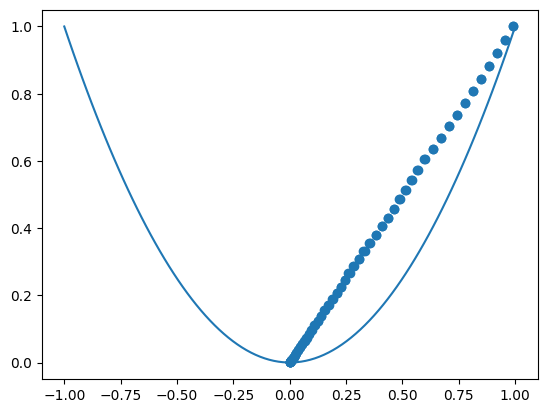

In [ ]:
hist = train(x,y,model,loss_fn,optimizer)
plt.plot(hist)
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()
print(model(x))
plt.plot(x,y)
plt.scatter(model(x).detach(),y)